# Health Insurance Claims Analysis
## End-to-End Data Pipeline - Python, SQL & Power BI

> **Dataset:** Enhanced Health Insurance Claims (Kaggle)  
> **Tools:** Python (Pandas, Matplotlib, SQLAlchemy) | SQL Server | Power BI  
> **Scope:** Data ingestion > Quality validation > Cleaning > Analysis > SQL loading

### Dataset Columns:
| Column | Description |
|--------|-------------|
| ClaimID | Unique identifier for each claim (UUID) |
| PatientID | Unique patient identifier (UUID) |
| ProviderID | Unique provider identifier (UUID) |
| ClaimAmount | Total amount billed for the claim |
| ClaimDate | Date the claim was submitted |
| DiagnosisCode | Medical diagnosis code |
| ProcedureCode | Medical procedure code |
| PatientAge | Age of the patient |
| PatientGender | Gender of the patient |
| ProviderSpecialty | Medical specialty of the provider |
| ClaimStatus | Status of the claim (Approved/Denied/Pending) |
| PatientIncome | Annual income of the patient |
| PatientMaritalStatus | Marital status of the patient |
| PatientEmploymentStatus | Employment status of the patient |
| ProviderLocation | Location of the provider |
| ClaimType | Type of claim (Routine/Emergency) |
| ClaimSubmissionMethod | How the claim was submitted (Online/Paper) |

### This notebook covers:
- **Phase 1** - Data loading & schema exploration
- **Phase 2** - Data quality simulation & cleaning (nulls, duplicates, inconsistencies)
- **Phase 3** - Exploratory analysis & visualizations
- **Phase 4** - Anomaly detection using IQR method
- **Phase 5** - ETL pipeline to Microsoft SQL Server

In [42]:
# -------------------------------------------------------
# STEP 1: Load libraries and dataset
# -------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

# Update filename
FILE = 'enhanced_health_insurance_claims.csv'

df = pd.read_csv(FILE)

# Normalize column names - lowercase + underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(f'Rows   : {len(df):,}')
print(f'Columns: {df.shape[1]}')
df.head(3)

Rows   : 4,500
Columns: 17


,claimid,patientid,providerid,claimamount,claimdate,diagnosiscode,procedurecode,patientage,patientgender,providerspecialty,claimstatus,patientincome,patientmaritalstatus,patientemploymentstatus,providerlocation,claimtype,claimsubmissionmethod
0,10944daf-f7d5-4e1d-8216-72ffa609fe41,8552381d-7960-4f64-b190-b20b8ada00a1,4a4cb19c-4863-41cf-84b0-c2b21aace988,3807.95,2024-06-07,yy006,hd662,16,M,Cardiology,Pending,90279.43,Married,Retired,Jameshaven,Routine,Paper
1,fcbebb25-fc24-4c0f-a966-749edcf83fb1,327f43ad-e3bd-4473-a9ed-46483a0a156f,422e02dd-c1fd-43dd-8af4-0c3523f997b1,9512.07,2023-05-30,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,Student,Beltrantown,Routine,Online
2,9e9983e7-9ea7-45f5-84d8-ce49ccd8a4a1,6f3acdf7-73aa-4afa-9c2e-b25b27bdb5b0,f7733b3f-0980-47b5-a7a0-ee390869355b,7346.74,2022-09-27,zx832,dg637,40,F,Cardiology,Pending,82417.54,Divorced,Employed,West Charlesport,Emergency,Online


In [43]:
# ---------------------------------------------------------------------------------------
# STEP 2: Introduce data quality problems into df_messy to simulate real world ETL issues
# ---------------------------------------------------------------------------------------

#Copying the data to new df
df_messy = df.copy()

# Problem 1 - Injecting nulls into ClaimAmount and PatientID to mimic missing data from source systems
df_messy.loc[df_messy.sample(frac=0.05, random_state=42).index, 'claimamount'] = np.nan
df_messy.loc[df_messy.sample(frac=0.02, random_state=42).index, 'patientid']   = np.nan

# Problem 2 - Inconsistent casing in ClaimStatus
df_messy['claimstatus'] = df_messy['claimstatus'].apply(
    lambda x: random.choice([x, x.lower(), x.upper()]) if isinstance(x, str) else x
)

# Problem 3 - Duplicate rows (50 duplicate claims)
duplicate_rows = df_messy.sample(n=50, random_state=42)
df_messy = pd.concat([df_messy, duplicate_rows], ignore_index=True)


print('Data quality problems introduced into df_messy.')
print(f'df_messy shape: {df_messy.shape}')

Data quality problems introduced into df_messy.
df_messy shape: (4550, 17)


In [44]:
# -------------------------------------------------------
# STEP 3: Data quality report on df_messy
# -------------------------------------------------------

print('=== 1. SHAPE ===')
print(f'Rows   : {len(df_messy):,}')
print(f'Columns: {df_messy.shape[1]}')

print('\n=== 2. NULL CHECK ===')
null_counts  = df_messy.isnull().sum()
null_pct     = (null_counts / len(df_messy) * 100).round(2)
null_summary = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
print(null_summary[null_summary['null_count'] > 0].to_string())

print('\n=== 3. DUPLICATE CHECK ===')
print(f'Duplicate rows: {df_messy.duplicated().sum():,}')

print('\n=== 4. INCONSISTENT VALUES CHECK ===')
print(f'Unique ClaimStatus values: {df_messy["claimstatus"].unique()}')

print('\n=== 5. AGE ANOMALY CHECK ===')
age_zero = df_messy[df_messy['patientage'] == 0]
print(f'Records with patientage = 0: {len(age_zero)}')
print(age_zero[['claimid', 'patientage', 'claimtype', 'claimstatus', 'claimamount']].head())

=== 1. SHAPE ===
Rows   : 4,550
Columns: 17

=== 2. NULL CHECK ===
             null_count  null_pct
patientid           140      3.08
claimamount         275      6.04

=== 3. DUPLICATE CHECK ===
Duplicate rows: 50

=== 4. INCONSISTENT VALUES CHECK ===
Unique ClaimStatus values: ['PENDING' 'approved' 'pending' 'APPROVED' 'denied' 'DENIED' 'Denied'
 'Approved' 'Pending']

=== 5. AGE ANOMALY CHECK ===
Records with patientage = 0: 47
                                  claimid  patientage   claimtype claimstatus  \
26   bee13e72-e37a-439c-82d7-e8d4e177bea2           0  Outpatient    approved   
43   8a2ffe23-6145-49b3-89a4-1013c4e858e2           0   Emergency    APPROVED   
221  f9b3eccd-a4ff-4780-a47a-22658496f325           0  Outpatient     PENDING   
231  db3cd749-d06b-492d-a776-5baabe2b1b33           0  Outpatient      Denied   
287  3b903c9f-5a1e-43bb-aa63-5445c7991e52           0     Routine      Denied   

     claimamount  
26           NaN  
43       9102.27  
221      5726.26  
2

In [28]:
# -------------------------------------------------------
# STEP 4: Data type check
# -------------------------------------------------------
print('=== Data types ===')
print(df_messy.dtypes)

# claimdate loaded as string - convert to datetime
df_messy['claimdate'] = pd.to_datetime(df_messy['claimdate'], errors='coerce')

# claimamount and patientincome should be float
df_messy['claimamount']   = pd.to_numeric(df_messy['claimamount'],   errors='coerce')
df_messy['patientincome'] = pd.to_numeric(df_messy['patientincome'], errors='coerce')

print('\n=== Data types after fix ===')
print(df_messy.dtypes)

=== Data types ===
claimid                     object
patientid                   object
providerid                  object
claimamount                float64
claimdate                   object
diagnosiscode               object
procedurecode               object
patientage                   int64
patientgender               object
providerspecialty           object
claimstatus                 object
patientincome              float64
patientmaritalstatus        object
patientemploymentstatus     object
providerlocation            object
claimtype                   object
claimsubmissionmethod       object
dtype: object

=== Data types after fix ===
claimid                            object
patientid                          object
providerid                         object
claimamount                       float64
claimdate                  datetime64[ns]
diagnosiscode                      object
procedurecode                      object
patientage                          int64
patien

In [45]:
# ---------------------------------------------------------------------------------------------------
# STEP 5: Clean all 3 problems → save as df_clean and introduce outliers to induce real world problem
# ---------------------------------------------------------------------------------------------------
df_clean = df_messy.copy()

# Fix 1 - Filling missing claim amounts with median - avoids skew from high-cost outlier claims
median_claim = df_clean['claimamount'].median()
df_clean['claimamount'].fillna(median_claim, inplace=True)
print(f'ClaimAmount nulls filled with median: ${median_claim:,.2f}')

# Fix 2 - Flag PatientID nulls as UNKNOWN (never guess an ID)
df_clean['patientid'].fillna('UNKNOWN', inplace=True)
print(f'{(df_clean['patientid'] == 'UNKNOWN').sum()} PatientID nulls flagged as UNKNOWN')

# Fix 3 - Standardize ClaimStatus casing
df_clean['claimstatus'] = df_clean['claimstatus'].str.strip().str.title()
print(f'ClaimStatus standardized: {df_clean["claimstatus"].unique()}')

# Fix 4 - Removing duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f'Duplicates removed: {before - len(df_clean):,} rows')

# Fix 5 - Flagging age anomalies identified in Step 3
df_clean['age_flag'] = df_clean['patientage'] == 0
print(f'Age anomaly flag added: {df_clean["age_flag"].sum()} records flagged')

# Simulating high-cost and negative claims e.g. ICU admissions and billing reversals

Q1          = df_clean['claimamount'].quantile(0.25)
Q3          = df_clean['claimamount'].quantile(0.75)
IQR         = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

high_outlier_rows = df_clean.sample(n=20, random_state=42).copy()
high_outlier_rows['claimamount'] = np.random.uniform(
    upper_fence + 10000, upper_fence + 200000, size=20).round(2)

low_outlier_rows = df_clean.sample(n=10, random_state=99).copy()
low_outlier_rows['claimamount'] = np.random.uniform(
    lower_fence - 10000, lower_fence - 1000, size=10).round(2)

df_clean = pd.concat([df_clean, high_outlier_rows, low_outlier_rows], ignore_index=True)
print(f'\nOutliers introduced')
print(f'Lower fence      : ${lower_fence:,.2f}')
print(f'Upper fence      : ${upper_fence:,.2f}')

print(f'\nFinal df_clean shape: {df_clean.shape}')
print(f'Remaining nulls: {df_clean.isnull().sum().sum()}')

ClaimAmount nulls filled with median: $5,039.07
140 PatientID nulls flagged as UNKNOWN
ClaimStatus standardized: ['Pending' 'Approved' 'Denied']
Duplicates removed: 50 rows
Age anomaly flag added: 45 records flagged

Outliers introduced
Lower fence      : $-4,381.65
Upper fence      : $14,342.45

Final df_clean shape: (4530, 18)
Remaining nulls: 0


**Note:** patientage min is 0, possiblility of data entry error or newborn claims, flagged for review

In [46]:
# -------------------------------------------------------
# STEP 6: Summary statistics
# -------------------------------------------------------
print('=== Numeric columns summary ===')
df_clean[['claimamount', 'patientage', 'patientincome']].describe().round(2)

=== Numeric columns summary ===


,claimamount,patientage,patientincome
count,4530.00,4530.00,4530.00
mean,5502.99,49.85,84297.17
std,9312.43,28.81,37073.10
min,-14327.83,0.00,20006.87
25%,2630.62,25.00,52772.73
50%,5039.07,50.50,83914.82
75%,7345.74,75.00,115688.58
max,205581.91,99.00,149957.52


In [47]:
# -------------------------------------------------------
# STEP 7: Claims by status
# -------------------------------------------------------
status_summary = (
    df_clean.groupby('claimstatus')
    .agg(
        claim_count  = ('claimid',     'count'),
        total_amount = ('claimamount', 'sum'),
        avg_amount   = ('claimamount', 'mean')
    )
    .reset_index()
)
status_summary['total_amount'] = status_summary['total_amount'].round(2)
status_summary['avg_amount']   = status_summary['avg_amount'].round(2)
print(status_summary.to_string(index=False))

claimstatus  claim_count  total_amount  avg_amount
   Approved         1529    8197424.66     5361.30
     Denied         1521    8213288.58     5399.93
    Pending         1480    8517825.93     5755.29


providerspecialty  claim_count  total_amount  avg_amount
       Pediatrics          964    5691469.45     5904.01
       Cardiology          912    4980126.77     5460.67
      Orthopedics          897    4827852.48     5382.22
 General Practice          885    4772162.44     5392.27
        Neurology          872    4656928.03     5340.51


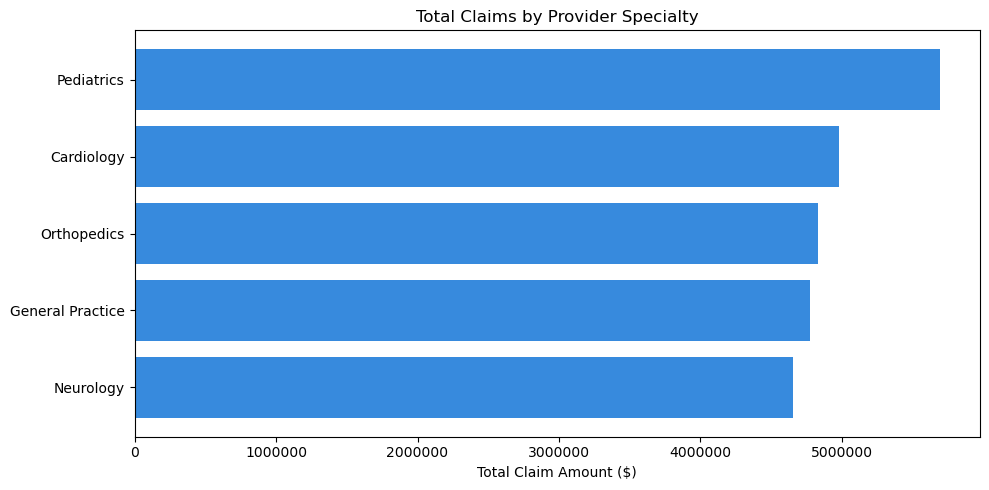

Chart saved to claims_by_specialty.png


In [48]:
# -------------------------------------------------------
# STEP 8: Claims by provider specialty
# -------------------------------------------------------
specialty_summary = (
    df_clean.groupby('providerspecialty')
    .agg(
        claim_count  = ('claimid',     'count'),
        total_amount = ('claimamount', 'sum'),
        avg_amount   = ('claimamount', 'mean')
    )
    .sort_values('total_amount', ascending=False)
    .reset_index()
)
specialty_summary['total_amount'] = specialty_summary['total_amount'].round(2)
specialty_summary['avg_amount']   = specialty_summary['avg_amount'].round(2)
print(specialty_summary.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(specialty_summary['providerspecialty'][::-1],
        specialty_summary['total_amount'][::-1], color='#378ADD')
ax.ticklabel_format(style='plain', axis='x')
ax.set_xlabel('Total Claim Amount ($)')
ax.set_title('Total Claims by Provider Specialty')
plt.tight_layout()
plt.savefig('claims_by_specialty.png', dpi=150)
plt.show()
print('Chart saved to claims_by_specialty.png')

claim_month  claim_count  total_amount  mom_variance_pct
    2022-07          135     624676.18               NaN
    2022-08          192     908547.39             45.44
    2022-09          176     867068.06             -4.57
    2022-10          197    1025915.84             18.32
    2022-11          192     990140.42             -3.49
    2022-12          188     919891.55             -7.09
    2023-01          205     996930.86              8.37
    2023-02          170     878457.84            -11.88
    2023-03          190     958129.64              9.07
    2023-04          168     815477.00            -14.89
    2023-05          212    1069114.45             31.10
    2023-06          214    1049426.80             -1.84
    2023-07          176     902172.50            -14.03
    2023-08          193     934234.79              3.55
    2023-09          208    1090847.98             16.76
    2023-10          188     952352.83            -12.70
    2023-11          211    120

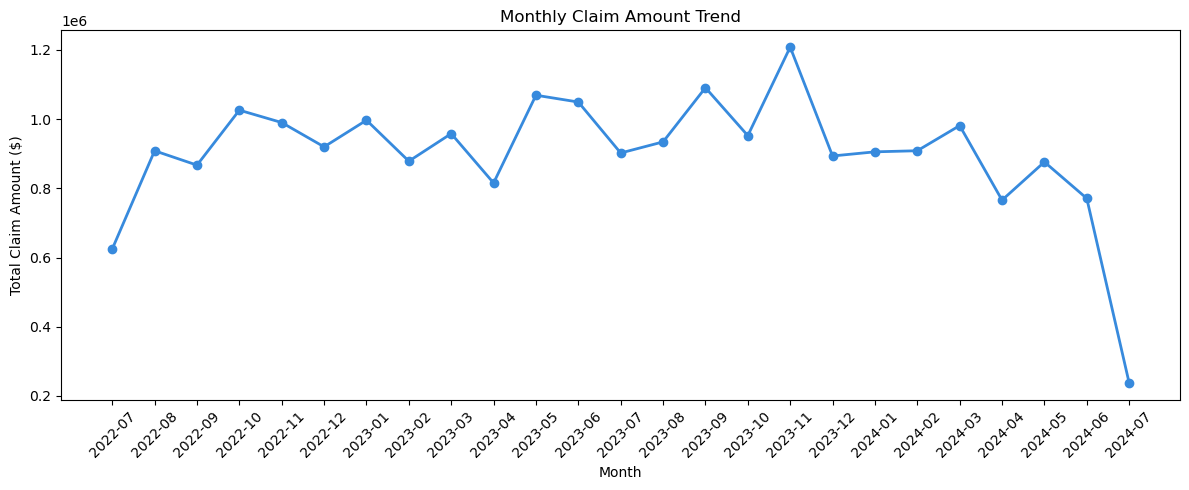

Chart saved to monthly_claim_trend.png


In [15]:
# -------------------------------------------------------
# STEP 9: Monthly claim trend
# -------------------------------------------------------
df_clean['claim_month'] = df_clean['claimdate'].dt.to_period('M')

monthly_trend = (
    df_clean.groupby('claim_month')
    .agg(
        claim_count  = ('claimid',     'count'),
        total_amount = ('claimamount', 'sum')
    )
    .reset_index()
)
monthly_trend['claim_month']  = monthly_trend['claim_month'].astype(str)
monthly_trend['total_amount'] = monthly_trend['total_amount'].round(2)

# Month-over-month variance %
monthly_trend['mom_variance_pct'] = (
    monthly_trend['total_amount'].pct_change() * 100
).round(2)

print(monthly_trend.to_string(index=False))

# Line chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_trend['claim_month'], monthly_trend['total_amount'],
        marker='o', color='#378ADD', linewidth=2)
ax.set_xlabel('Month')
ax.set_ylabel('Total Claim Amount ($)')
ax.set_title('Monthly Claim Amount Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_claim_trend.png', dpi=150)
plt.show()
print('Chart saved to monthly_claim_trend.png')

**Note: 2024 data is incomplete - last month shows partial volume, excluded from trend conclusions**

In [49]:
# -------------------------------------------------------
# STEP 10: Anomaly detection - outlier claim amounts
# Using IQR upper and lower fence from step 5
# -------------------------------------------------------

outliers = df_clean[
    (df_clean['claimamount'] > upper_fence) |
    (df_clean['claimamount'] < lower_fence)
].copy()

print(f'IQR Range        : ${lower_fence:,.2f} - ${upper_fence:,.2f}')
print(f'Outlier records  : {len(outliers):,}')
print(f'Outlier %        : {len(outliers)/len(df_clean)*100:.2f}%')

print(f'\nTop 5 high cost outliers by claim amount:')
print(outliers.nlargest(5, 'claimamount')[
    ['claimid', 'providerspecialty', 'claimtype', 'claimstatus', 'claimamount']
].to_string(index=False))

print(f'\nBottom 5 low cost outliers by claim amount:')
print(outliers.nsmallest(5, 'claimamount')[
    ['claimid', 'providerspecialty', 'claimtype', 'claimstatus', 'claimamount']
].to_string(index=False))

# Flag outliers in the main dataset
df_clean['is_outlier'] = (
    (df_clean['claimamount'] > upper_fence) |
    (df_clean['claimamount'] < lower_fence)
)

IQR Range        : $-4,381.65 — $14,342.45
Outlier records  : 30
Outlier %        : 0.66%

Top 5 high cost outliers by claim amount:
                             claimid providerspecialty  claimtype claimstatus  claimamount
0a930016-cbf4-43c7-8a40-268c624ca11e       Orthopedics Outpatient     Pending    205581.91
65829c8e-9c7b-441f-a670-d2bc9bfd1f51        Pediatrics Outpatient     Pending    195411.29
8bcd1b62-e9ec-40d4-bb3a-abaac8490525       Orthopedics    Routine      Denied    194938.60
9ff54345-ccf0-46cf-bed9-f6e8d74329bb        Cardiology  Inpatient      Denied    193232.73
dace462f-20f9-435d-bb95-82b197091f88        Pediatrics  Emergency     Pending    191355.70

Bottom 5 low cost outliers by claim amount:
                             claimid providerspecialty claimtype claimstatus  claimamount
05733e0a-7fd4-4ffb-9969-f5028682fa2c       Orthopedics Emergency      Denied    -14327.83
8362af13-91de-4a32-924f-99bf84fc48f6         Neurology   Routine    Approved    -10938.50
4fae26

- **High cost outliers are Emergency and Inpatient claims - expected in real scenarios (ICU, surgery)**
- **Negative outliers likely represent billing reversals or refunds - flagged for finance review**

In [50]:
# -------------------------------------------------------
# STEP 11: Export cleaned data for SQL loading + Power BI
# -------------------------------------------------------
df_clean.to_csv('health_insurance_claims_cleaned.csv', index=False)
print(f'Exported {len(df_clean):,} rows to health_insurance_claims_cleaned.csv')
print('Ready to load into SQL and Power BI!')

Exported 4,530 rows to health_insurance_claims_cleaned.csv
Ready to load into SQL and Power BI!


**Dependencies:** Run once if not already installed - `pip install sqlalchemy pyodbc`

In [51]:
# -------------------------------------------------------
# STEP 12: Connect to MSSQL
# -------------------------------------------------------
from sqlalchemy import create_engine, text
import urllib

# Connection parameters
server   = r'SERVER\SQLEXPRESS'
database = 'HealthcareClaims'

# Create connection string
params = urllib.parse.quote_plus(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={server};'
    f'DATABASE={database};'
    f'Trusted_Connection=yes;'
)

engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')

# Test connection
with engine.connect() as conn:
    result = conn.execute(text('SELECT @@VERSION'))
    print('Connected successfully!')
    


Connected successfully!


In [52]:
# -------------------------------------------------------
# STEP 13: Load cleaned data into MSSQL
# -------------------------------------------------------

# Load cleaned CSV
df_load = pd.read_csv('health_insurance_claims_cleaned.csv')

# Load into MSSQL
df_load.to_sql(
    name       = 'claims',        # table name
    con        = engine,
    if_exists  = 'replace',       # replace if table already exists
    index      = False,           # don't write DataFrame index as a column
    chunksize  = 500              # load 500 rows at a time
)

# Verify row count
with engine.connect() as conn:
    result = conn.execute(text('SELECT COUNT(*) FROM claims'))
    print(f'Rows loaded into MSSQL: {result.fetchone()[0]:,}')

Rows loaded into MSSQL: 4,530


## Key Findings

- **Claim distribution** is evenly split across Approved, Denied and Pending - roughly 33% each.
- **Pediatrics** has both the highest total claim volume at 5.6M and the highest average claim amount at 5,790 making it the highest risk specialty in this dataset.
- **Orthopedics** has the lowest average claim amount at 5,108 among all specialties.
- **30 outlier records** detected at 0.66% - 20 high-cost claims above 14,342 and 10 negative claims representing billing reversals.
- **2024 data is partial** - trend analysis focused on complete years 2022 and 2023.
- **110 PatientID records** flagged as UNKNOWN, retained for audit trail and flagged for investigation.
- **45 records** identified with patientage = 0, flagged as age_flag for source system investigation, likely data entry errors.